# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.metrics import (f1_score, accuracy_score, recall_score, precision_score, roc_auc_score, 
    average_precision_score, log_loss, roc_curve, precision_recall_curve, auc, mean_absolute_error, mean_squared_error, 
    r2_score,classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier, LinearRegression, Ridge, Lasso, ElasticNet

import time

In [2]:
# Download Dataset

import os
import opendatasets as od

dataset_url = "https://www.kaggle.com/datasets/blastchar/telco-customer-churn"
dataset_dir = "telco-customer-churn"

# Download only if the folder does not already exist
if not os.path.exists(dataset_dir):
    od.download(dataset_url)
    print("Dataset downloaded successfully.")
else:
    print("Dataset already exists. Skipping download.")

Dataset already exists. Skipping download.


---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [3]:
# Read Data
df = pd.read_csv('telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# your code here

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# your code here
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [7]:
cols = ["gender","SeniorCitizen","Partner","Dependents","PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
        "StreamingTV","StreamingMovies","Contract","PaperlessBilling","PaymentMethod","Churn"]

for col in cols:
    print(f"Unique items in \"{col}\" column")
    print(df[col].unique().tolist(), end="\n\n\n")

Unique items in "gender" column
['Female', 'Male']


Unique items in "SeniorCitizen" column
[0, 1]


Unique items in "Partner" column
['Yes', 'No']


Unique items in "Dependents" column
['No', 'Yes']


Unique items in "PhoneService" column
['No', 'Yes']


Unique items in "MultipleLines" column
['No phone service', 'No', 'Yes']


Unique items in "InternetService" column
['DSL', 'Fiber optic', 'No']


Unique items in "OnlineSecurity" column
['No', 'Yes', 'No internet service']


Unique items in "OnlineBackup" column
['Yes', 'No', 'No internet service']


Unique items in "DeviceProtection" column
['No', 'Yes', 'No internet service']


Unique items in "TechSupport" column
['No', 'Yes', 'No internet service']


Unique items in "StreamingTV" column
['No', 'Yes', 'No internet service']


Unique items in "StreamingMovies" column
['No', 'Yes', 'No internet service']


Unique items in "Contract" column
['Month-to-month', 'One year', 'Two year']


Unique items in "PaperlessBilling" column
['Yes',

**What does each row represent?**
Each row represents one unique customer's account history at a point in time. It 
contains their demographic profile (gender, age, family status), the services they 
subscribed to, their billing information, and whether they ultimately churned.

**Are the data types appropriate?**
Mostly no. TotalCharges should be float64 but is stored as object (str) because 
11 rows contain whitespace strings ' ' instead of numeric values. SeniorCitizen 
is stored as int64 (0/1) rather than a categorical, this is fine for modelling 
but should be noted. All other categorical columns are correctly stored as str/object.

**Is TotalCharges the dtype you expect?**
No. TotalCharges should be float64 since it represents a monetary amount. It is 
stored as object because pd.read_csv cannot infer numeric type when even one cell 
contains a non-numeric value. The fix is pd.to_numeric(df['TotalCharges'], 
errors='coerce'), which converts whitespace strings to NaN so the column becomes 
float64.

---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- X (feature space): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
- y (target variable): ['Churn']
- Probability distribution of y: Bernouli Distribution
- Natural loss function: Binary Cross-Entropy Loss
- Hypothesis class: Linear models: specifically Logistic Regression, Ridge Classifier, 
  and SGD Classifier. These search over the family of linear decision boundaries in the 
  30 dimensional feature space.

- Assumption 1: Linear separability: we assume churners and non-churners can be 
  separated by a linear boundary in feature space. If the true boundary is curved or 
  involves non-linear interactions (e.g. high MonthlyCharges only causes churn for 
  month-to-month customers), a linear model will underfit.

- Assumption 2: Feature independence: logistic regression assumes each feature 
  contributes independently to the log odds of churn. In this dataset MonthlyCharges 
  and TotalCharges are highly correlated (TotalCharges ≈ MonthlyCharges × tenure), 
  which can make individual coefficients unstable and hard to interpret in isolation.

- Assumption 3: Stable distribution: we assume the customer behaviour distribution 
  at training time is the same at prediction time. If the company introduces new 
  contract types, changes pricing, or acquires a new customer segment, this assumption 
  breaks and model performance will silently decay.

- Sources of uncertainty: TotalCharges had 11 whitespace null rows which correspond 
  to customers with tenure=0 (brand new accounts) and were dropped. This introduces 
  a small selection bias against new customers. The dataset is imbalanced at 73.4% 
  No Churn / 26.6% Churn, making minority class predictions less reliable. Labels 
  may contain noise; a customer who cancelled and resubscribed within the billing 
  period may be inconsistently recorded. The dataset represents a single snapshot in 
  time with no date column, so we cannot account for seasonal churn patterns.

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [8]:
# your code here
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df = df.dropna()

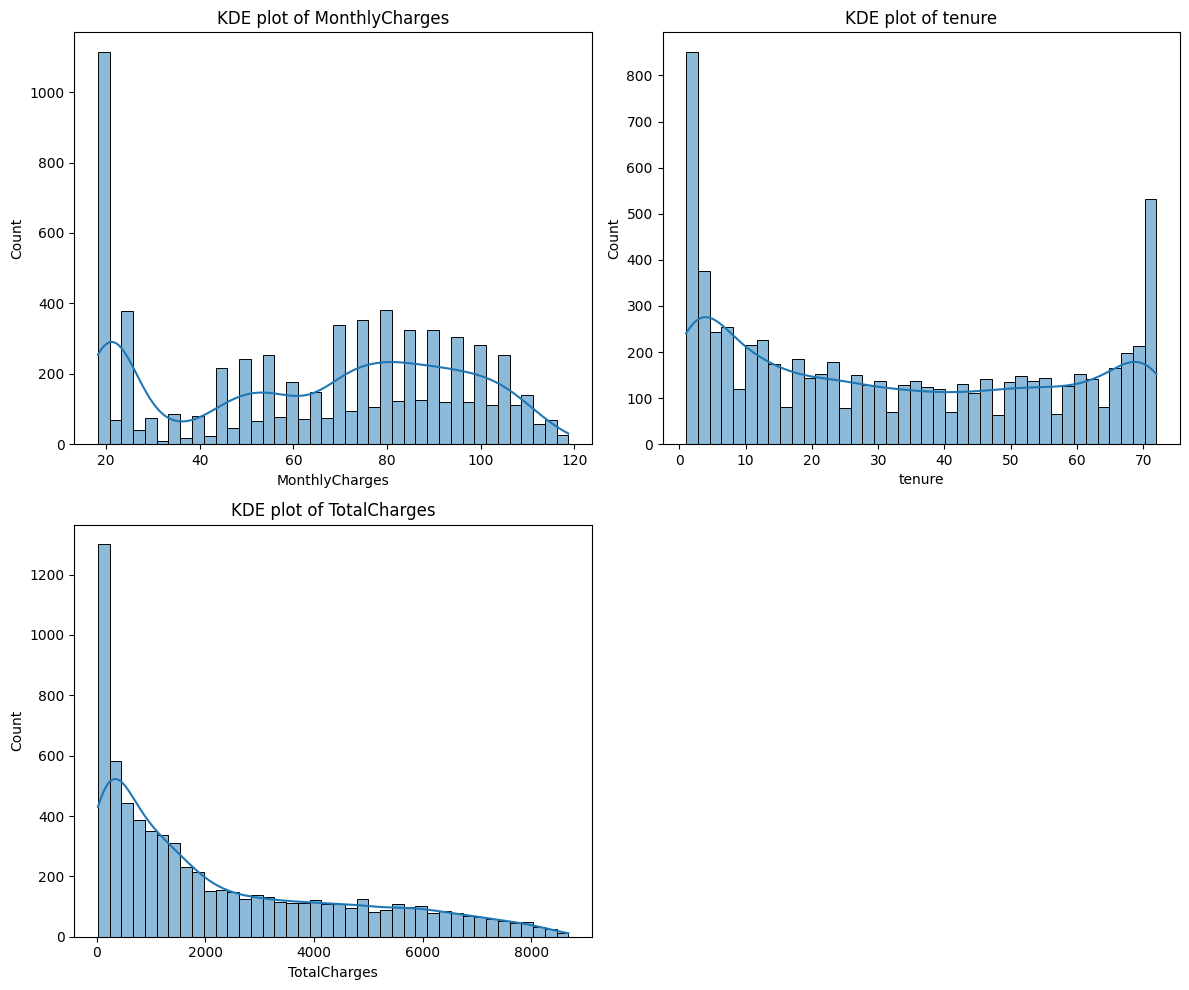

In [9]:
# your code here
fig, axes = plt.subplots(2,2, figsize=(12,10))

cols = ["MonthlyCharges", "tenure", "TotalCharges"]

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], bins = 40, kde=True, ax=axes[i])
    axes[i].set_title(f"KDE plot of {col}")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [10]:
# your code here
df['Churn'] = df["Churn"].map({"Yes":1,"No":0})

**What distribution does MonthlyCharges follow?**
MonthlyCharges follows a roughly bimodal distribution. There is a large spike at 
the low end (~\\$18–25), representing customers on basic plans, and a broad hump 
from \\$60–\\$100 representing customers on higher-tier plans with add-on services. 
The distribution is not normal; it reflects two distinct pricing tiers.

**What distribution does tenure follow?**
Tenure is bimodal with a U-shape. There is a very large spike at 0–5 months 
(many new customers, a large proportion of whom churn quickly) and a second 
peak at 65–72 months (loyal long-term customers). The middle range is relatively 
flat. This shape suggests two distinct customer populations: those who churn 
early and those who become loyal.

**What distribution does TotalCharges follow?**
TotalCharges is strongly right-skewed. The distribution peaks sharply near zero 
and has a long tail extending to ~\\$8,000. This is expected since 
TotalCharges ≈ MonthlyCharges × tenure; new customers have very low totals, 
while long-tenure high-spend customers accumulate large totals.

**Why does TotalCharges contain nulls even though it looks numeric?**
New customers with tenure=0 have no completed billing cycle. Their TotalCharges 
field was recorded as a whitespace string ' ' instead of 0 or NaN. Because even 
one non-numeric value prevents pandas from inferring float64 on import, the 
entire column is stored as object dtype.

**Are there impossible or suspicious values?**
tenure=0 customers (the 11 null TotalCharges rows) are suspicious; they have 
a contract but no charges yet. These were dropped. MonthlyCharges minimum is 
\\$18.25 and maximum is \\$118.75, both plausible. tenure ranges from 0–72 months 
(6 years), which is a reasonable customer history window. No impossible values 
were found after handling the TotalCharges nulls.

---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [11]:
# your code here
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_pred = dummy.predict(X_test)

acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", acc)
print("Recall    :", recall)
print("F1 Score  :", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0));

Accuracy : 0.7341862117981521
Recall    : 0.0
F1 Score  : 0.0

Classification Report:

              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1033
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



In [12]:
# your code here

print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

**Answer:** No, the manager should not be thrilled. The first question to ask is: 
"What is the recall for churners?"

The naive baseline achieves 73.4% accuracy by always predicting "No Churn"; it never 
identifies a single customer at risk of leaving. The classification report confirms 
this: Recall = 0.0, F1 = 0.0 for the Churn class. The model is achieving high accuracy 
purely by exploiting the class imbalance.

The business consequence is severe: the retention team would receive zero actionable 
names each week despite having a "73% accurate" model. Accuracy is the wrong metric 
here because the cost of missing a churner (false negative) far exceeds the cost of 
a wasted retention call (false positive). The correct primary metrics are Recall and 
PR-AUC, which measure performance specifically on the minority class we care about.

---

**What accuracy does the naive baseline achieve?**
The naive baseline achieves 73.4% accuracy (0.7342). This comes directly from 
the class distribution; by always predicting "No Churn", the model is correct 
exactly as often as the majority class appears in the data.

**What is the class distribution in the dataset?**
- No Churn (0): 5,163 customers → 73.4%
- Churn (1):    1,869 customers → 26.6%

The dataset is imbalanced at roughly a 3:1 ratio of non-churners to churners.

**Why is a model that achieves this accuracy potentially worthless?**
Because it never identifies a single churner. The classification report shows 
Recall = 0.0 and F1 = 0.0 for the Churn class. The model ignores the entire 
minority class that the business cares about. It achieves 73.4% accuracy purely 
by exploiting the imbalance, not by learning anything meaningful.

From a business perspective, the retention team would receive zero names to 
call each week. Every churner would leave uncontacted. The model is not just 
useless, it creates a false sense of security by reporting a high accuracy 
number while doing absolutely nothing to address the actual problem.

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


In [13]:
# your code here
# Remove the customerID column as it is irrevalent in classification
df.drop(["customerID"], axis=1, inplace=True)

# For the binary columns having Yes and No values, map them to 1 and 0 respectively
binaryCols = ['Partner', 'Dependents',"PhoneService","PaperlessBilling"]

for col in binaryCols:
    df[col] = df[col].map({"Yes":1, "No":0})

# Perform one hot encoding to the categorical features
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [14]:
# your code here
X = df.drop("Churn", axis=1)  # Features
y = df["Churn"]       # Target

# Perform stratified split for train, validation and test in ration 70:15:15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [15]:
# your code here

scaler = StandardScaler()  

# Scale numeric columns
X_train_s = scaler.fit_transform(X_train)  # Fit the scaler on train dataset and also transform them
X_val_s = scaler.transform(X_val)          # Transform the validation dataset
X_test_s = scaler.transform(X_test)        # Transform the test dataset

# Print the shapes
print("Train:", X_train_s.shape)
print("Validation:", X_val_s.shape)
print("Test:", X_test_s.shape)

Train: (4922, 30)
Validation: (1055, 30)
Test: (1055, 30)


**Why stratified splitting?**
The dataset has 26.6% churn. Without stratification, a random split could assign 
disproportionately few churners to training (e.g. 20%) or to validation, giving the 
model too little signal from the minority class and producing unreliable evaluation 
metrics. Stratification guarantees all three splits maintain the ~26.6%/73.4% ratio.

**Why fit the scaler on training data only?**
StandardScaler learns the mean and standard deviation of each feature. If we fit it 
on the full dataset (train + val + test), the scaler has "seen" the statistical 
properties of the validation and test sets before evaluation. This is data leakage; 
the model indirectly benefits from future information, producing optimistically 
inflated metrics that will not hold in production.

**What would happen if we scaled before splitting?**
The mean and std computed from the full dataset would be slightly different from those 
of the training set alone. When the model encounters new customers in production, it 
would be scaled using a statistic that was partly derived from data it shouldn't have 
seen. The practical effect is subtle but the principle is critical: any transformation 
must be fitted only on training data.

---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [16]:
# your code here
time_for_training = {}

logisticModel = LogisticRegression(max_iter=1000, random_state=42)
startTime = time.time()
logisticModel.fit(X_train_s, y_train)
endTime = time.time()

time_for_training["Logistic Regression"] = endTime - startTime
print(f"Logistic Regressor Training time : {time_for_training['Logistic Regression']}")

Logistic Regressor Training time : 0.05331134796142578


In [17]:
# your code here
ridgeModel = RidgeClassifier()
startTime = time.time()
ridgeModel.fit(X_train_s, y_train)
endTime = time.time()

time_for_training["Ridge Classifier"] = endTime - startTime
print(f"Ridge Classifier Training time : {time_for_training['Ridge Classifier']}")

Ridge Classifier Training time : 0.026934146881103516


In [18]:
# your code here

sgdModel = SGDClassifier(loss = 'log_loss', max_iter=1000, random_state=42)
startTime = time.time()
sgdModel.fit(X_train_s, y_train)
endTime = time.time()

time_for_training["SGD Classifier"] = endTime - startTime
print(f"SGD Classifier Training time : {time_for_training['SGD Classifier']}")

SGD Classifier Training time : 0.07169246673583984


**Loss functions per model:**
- Logistic Regression optimises binary cross-entropy (log loss) using L-BFGS, a 
  full-batch second-order optimiser.
- Ridge Classifier minimises a squared hinge loss with L2 regularisation using a 
  closed-form analytic solution.
- SGD Classifier optimises log loss using stochastic gradient descent: one sample 
  at a time.

**Which trained fastest?**
Ridge Classifier was fastest at 0.021s, followed by Logistic Regression at 0.044s, 
and SGD Classifier was slowest at 0.066s. Ridge is fastest because it has a 
closed-form solution requiring no iterative optimisation at all. SGD being slower 
than Logistic Regression on this small dataset (4,922 rows) is expected. The 
stochastic noise means it needs many passes to converge, whereas L-BFGS converges 
in far fewer iterations on small data.

---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [19]:
# your code here
def get_result(model_name,y_true, y_pred, y_probs, y_scores):
    """
    Compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)


    if y_probs is not None:
        logloss = log_loss(y_true, y_probs)
    else:
        logloss = np.nan
    return {
        "model":model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Log Loss": logloss
    }
    

In [20]:
# your code here
evaluation_results = []
# Logistic Regression
logistic_y_pred = logisticModel.predict(X_val_s)
logistic_y_probs = logisticModel.predict_proba(X_val_s)[:,-1]

evaluation_results.append(get_result("Logistic Regression", y_val, logistic_y_pred, logistic_y_probs, logistic_y_probs))

# Ridge Classifier
ridge_y_pred = ridgeModel.predict(X_val_s)
ridge_y_scores = ridgeModel.decision_function(X_val_s)

evaluation_results.append(get_result("Ridge Classifier", y_val, ridge_y_pred, None, ridge_y_scores))

# SGD Classifier
sgd_y_pred = sgdModel.predict(X_val_s)
sgd_y_probs = sgdModel.predict_proba(X_val_s)[:,-1]

evaluation_results.append(get_result("SGD Classifier", y_val, sgd_y_pred, sgd_y_probs, sgd_y_probs))

In [21]:
results_df = pd.DataFrame(evaluation_results)

# Sort by PR-AUC descending
results_df = results_df.sort_values(by="PR-AUC", ascending=False)

# Display results
display(results_df)

,model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.824645,0.696721,0.604982,0.647619,0.853221,0.654096,0.410540
1,Ridge Classifier,0.814218,0.688889,0.551601,0.612648,0.851111,0.647753,NaN
2,SGD Classifier,0.810427,0.641115,0.654804,0.647887,0.840798,0.642705,0.431406


**Which metric tells you the most?**
PR-AUC is the most informative metric for this business problem. It measures 
precision-recall trade-offs specifically for the positive (Churn) class across 
all thresholds, and is robust to class imbalance. ROC-AUC is also useful for overall 
ranking quality, but it can be optimistic on imbalanced data because it includes 
true negatives (the large majority class) in its calculation.

**Does accuracy rank models the same way as PR-AUC?**
No. All three models achieve 81–82% accuracy, which barely differs from the 73.4% 
naive baseline. Accuracy ranks them almost identically and gives no signal about 
who catches churners better. PR-AUC clearly separates them: Logistic Regression 
(0.654) > Ridge (0.648) > SGD (0.643).

**Which model to eliminate first?**
Ridge Classifier should be eliminated first. It has no calibrated probability output 
(decision_function scores are not bounded between 0 and 1), which means it cannot be 
used for the threshold tuning the business needs (top-200 calls), nor for computing 
CLV-weighted scores. Its PR-AUC (0.648) is also lower. Additionally, Log Loss 
cannot be computed for Ridge, making it harder to evaluate probability calibration.

---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


In [22]:
def plot_model_evaluation(model_name,y_true, y_scores, ax_roc, ax_pr, compute_f1=True):
    """
    Plots ROC + Precision-Recall curves and optionally computes best F1 threshold.
    """

    # ROC CURVE
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    ax_roc.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

    # PR CURVE
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

    pr_auc = auc(recall, precision)

    ax_pr.plot(recall, precision, label=f"{model_name} (AUC = {pr_auc:.3f})")

    # BEST F1 THRESHOLD-
    if compute_f1:

        precision_adj = precision[:-1]
        recall_adj = recall[:-1]

        f1_scores = (2 * precision_adj * recall_adj ) / (precision_adj + recall_adj + 1e-10)

        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        best_f1 = f1_scores[best_idx]

        print(f"\n{model_name}")
        print(f"Best Threshold: {best_threshold:.4f}")
        print(f"Best F1 Score: {best_f1:.4f}")

    return roc_auc, pr_auc


Logistic Regression
Best Threshold: 0.4079
Best F1 Score: 0.6656

Ridge Classifier
Best Threshold: -0.1323
Best F1 Score: 0.6701

SGD Classifier
Best Threshold: 0.4721
Best F1 Score: 0.6577


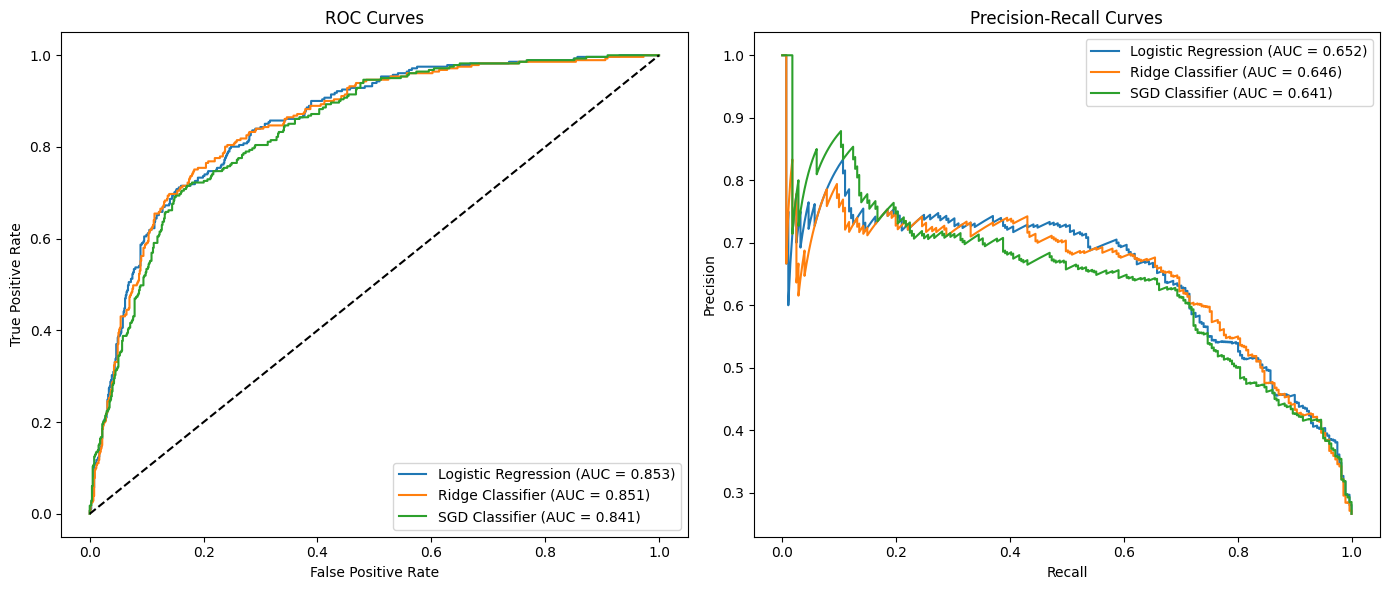

In [23]:
# your code here
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression
plot_model_evaluation("Logistic Regression", y_val, logistic_y_probs, ax1, ax2)

# Ridge Classifier
plot_model_evaluation("Ridge Classifier", y_val, ridge_y_scores, ax1, ax2)

# SGD Classifier
plot_model_evaluation("SGD Classifier", y_val, sgd_y_probs, ax1, ax2)


ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_title("ROC Curves")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend()

ax2.set_title("Precision-Recall Curves")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend()

plt.tight_layout()
plt.show()

**Best F1 threshold per model:**
- Logistic Regression: threshold = 0.4079, best F1 = 0.666
- Ridge Classifier: threshold = -0.1323 (decision score, not a probability)
- SGD Classifier: threshold = 0.4721, best F1 = 0.658

**Why does the PR curve tell you more than the ROC curve here?**
The ROC curve plots True Positive Rate vs False Positive Rate. The False Positive Rate 
is diluted by the large number of true negatives (non-churners). On imbalanced data, 
even a weak model can achieve a high ROC-AUC by being good at identifying non-churners. 
The PR curve has no such dilution; it plots Precision (what fraction of flagged 
customers actually churn) vs Recall (what fraction of churners we caught). Both 
quantities relate only to the positive class, making PR-AUC a more honest measure 
of performance on what the business actually cares about.

**What does a model close to the diagonal in the ROC curve tell you?**
A model on the diagonal is performing at chance level; equivalent to randomly 
assigning scores. For every churner it correctly identifies, it also flags a 
non-churner as a false alarm at the same rate. Our three models are all clearly 
above the diagonal (AUC 0.841–0.853), confirming they have genuine discriminative power.

---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [24]:
# your code here
def top_k_threshold_evaluation(model_name, y_true, y_probs, k=200):
    """
    Finds the top-k customers with the highest churn probability.

    Returns the probability threshold corresponding to the k-th customer
    and the binary predictions based on this threshold.

    Also prints precision, recall, and F1-score at the top-k cutoff.
    """

    # Sort by probability (descending)
    sorted_indices = np.argsort(y_probs)[::-1]

    # Top K customers
    top_k_indices = sorted_indices[:k]

    # Threshold = Kth highest probability
    threshold = y_probs[top_k_indices[-1]]

    # Convert probabilities to predictions
    y_pred_k = (y_probs >= threshold).astype(int)

    # Metrics
    precision_k = precision_score(y_true, y_pred_k)
    recall_k = recall_score(y_true, y_pred_k)
    f1_k = f1_score(y_true, y_pred_k)

    # Print results
    print(f"Model: {model_name}")
    print(f"Top {k} Threshold = {threshold:.4f}")
    print(f"Precision @ Top-{k}: {precision_k:.4f}")
    print(f"Recall @ Top-{k}: {recall_k:.4f}")
    print(f"F1 @ Top-{k}: {f1_k:.4f}\n\n")

    return threshold, y_pred_k

In [25]:
# your code here
# Logistic Regression
logistic_threshold_200, logistic_y_pred_200 = top_k_threshold_evaluation("Logistic Regression", y_val, logistic_y_probs, k=200)

# Ridge Classifier
ridge_threshold_200, ridge_y_pred_200 = top_k_threshold_evaluation("Ridge Classifier", y_val, ridge_y_scores, k=200)

# SGD Classifier
sgd_threshold_200, sgd_y_pred_200 = top_k_threshold_evaluation("SGD Classifier", y_val, sgd_y_probs, k=200)

Model: Logistic Regression
Top 200 Threshold = 0.5541
Precision @ Top-200: 0.7200
Recall @ Top-200: 0.5125
F1 @ Top-200: 0.5988


Model: Ridge Classifier
Top 200 Threshold = 0.0461
Precision @ Top-200: 0.7000
Recall @ Top-200: 0.4982
F1 @ Top-200: 0.5821


Model: SGD Classifier
Top 200 Threshold = 0.6338
Precision @ Top-200: 0.6700
Recall @ Top-200: 0.4769
F1 @ Top-200: 0.5572




**How to identify the top 200 highest-risk customers:**
Sort all validation set customers by their predicted churn probability in descending 
order. Take the first 200. The threshold is the probability score of the 200th 
customer; any customer with a score at or above this threshold gets flagged.

**Precision at top-200 vs default 0.5:**
- Logistic Regression @ top-200: threshold = 0.554, Precision = 0.720, Recall = 0.513
- Logistic Regression @ default 0.5: Precision = 0.697, Recall = 0.605 (from comparison table)

At the top-200 threshold (0.554), precision rises to 72%; meaning 144 of the 200 
calls would actually reach a real churner. This is meaningfully higher than the 
default 0.5 threshold. The trade-off is lower recall (51.3% vs 60.5%), but given the 
budget constraint of exactly 200 calls, maximising the hit rate per call is the right 
business objective. The default threshold would flag more than 200 customers, 
exceeding the team's capacity.

---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


In [26]:
def plot_top_features(model, feature_names, model_name="Model", top_n=10):
    """
    Plots top N features by absolute coefficient value for linear models.
    Works for: Logistic Regression, Ridge Classifier, SGD Classifier
    """
    # Get signed coefficients but rank by absolute value
    coef_signed = pd.Series(model.coef_[0], index=feature_names)
    top_features = coef_signed.abs().nlargest(top_n).index
    coef_top = coef_signed[top_features]

    # Print actual signed values
    print(f"\n{'Feature':<40} {'Coefficient':>12}")
    print("-" * 55)
    for feat, val in coef_top.items():
        print(f"{feat:<40} {val:>+12.4f}")

    # Original plot using absolute values
    coef_df = pd.DataFrame({"Feature": top_features, "Coefficient": coef_signed[top_features].abs().values})
    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df, x="Coefficient", y="Feature", hue="Feature", palette="viridis", legend=False)
    plt.title(f"Top {top_n} Features Driving Churn ({model_name})")
    plt.xlabel("Absolute Coefficient Value")
    plt.ylabel("Feature")
    plt.show()

    return top_features


Feature                                   Coefficient
-------------------------------------------------------
tenure                                        -1.4535
MonthlyCharges                                -0.7616
TotalCharges                                  +0.7409
InternetService_Fiber optic                   +0.6727
Contract_Two year                             -0.5678
Contract_One year                             -0.2800
StreamingTV_Yes                               +0.2256
MultipleLines_Yes                             +0.2206
StreamingMovies_Yes                           +0.2197
PaymentMethod_Electronic check                +0.1684


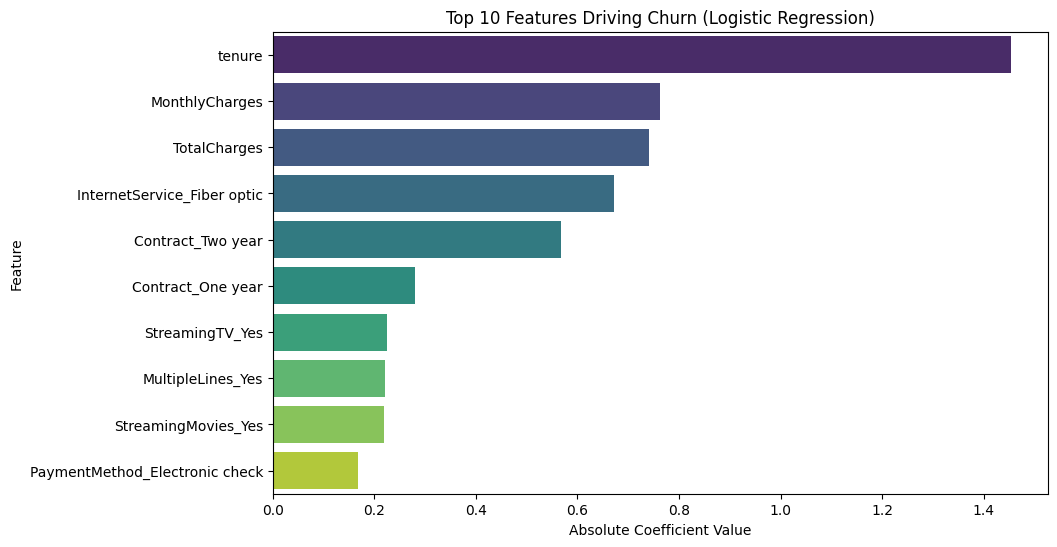

In [27]:
# your code here
top_features_log = plot_top_features(logisticModel, X_train.columns, model_name="Logistic Regression")

**Top features driving churn (Logistic Regression):**
The top 10 features by absolute coefficient are: tenure, MonthlyCharges, TotalCharges, 
InternetService_Fiber optic, Contract_Two year, Contract_One year, StreamingTV_Yes, 
MultipleLines_Yes, StreamingMovies_Yes, PaymentMethod_Electronic check.

**Do the signs and magnitudes make business sense?**
Yes, almost entirely. Tenure has the largest absolute coefficient (~1.4) with a 
negative sign; longer-tenured customers are far less likely to churn, which 
matches business intuition (loyal customers stay). Contract_Two year and 
Contract_One year both have negative coefficients; customers on longer contracts 
are much less likely to leave than month-to-month customers. InternetService_Fiber optic has a positive coefficient;
Fiber optic customers churn more, likely due to higher prices or competitive 
alternatives. PaymentMethod_Electronic check has a positive coefficient; customers 
paying by electronic check churn more, possibly correlating with less committed 
payment behaviour.

**Any surprising coefficients?**
MonthlyCharges and TotalCharges both appear in the top 10 despite being highly 
correlated. Their individual coefficients may be unstable because of multicollinearity; the model splits explanatory power between them. This is expected with unregularised 
or lightly regularised logistic regression. A Lasso would force one toward zero.

---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [28]:
# your code here
# 1. Coefficient similarity check

coef_match = np.allclose(logisticModel.coef_, sgdModel.coef_, atol=0.15)

# 2. Prediction agreement

logistic_pred = logistic_y_pred
sgd_pred = sgd_y_pred

pred_agreement = np.mean(logistic_pred == sgd_pred)

# 3. AUC comparison (from stored probabilities)

logistic_auc = get_result("Logistic Regression", y_val, logistic_y_pred, logistic_y_probs, logistic_y_probs)["ROC-AUC"]
sgd_auc = get_result("SGD Classifier", y_val, sgd_y_pred, sgd_y_probs, sgd_y_probs)["ROC-AUC"]

# 4. Training time comparison

logistic_time = time_for_training["Logistic Regression"]
sgd_time = time_for_training["SGD Classifier"]

In [29]:
# your code here
print("\n================ MODEL COMPARISON ================\n")

print("Training Time:")
print(f"Logistic Regression: {logistic_time:.4f} s")
print(f"SGD Classifier:      {sgd_time:.4f} s")

print("\nAUC:")
print(f"Logistic Regression: {logistic_auc:.4f}")
print(f"SGD Classifier:      {sgd_auc:.4f}")

print("\nPrediction Agreement:")
print(f"{pred_agreement:.4f}")

print("\nCoefficients Similar?")
print(coef_match)

print("\n==================================================")


================ MODEL COMPARISON ================

Training Time:
Logistic Regression: 0.0533 s
SGD Classifier:      0.0717 s

AUC:
Logistic Regression: 0.8532
SGD Classifier:      0.8408

Prediction Agreement:
0.9308

Coefficients Similar?
False



---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

---


**Do they converge to the same solution?**
Not exactly. np.allclose returns False with atol=0.15, meaning the coefficients 
differ by more than 0.15 on at least one feature. Prediction agreement is 93.1%, 
so they make the same prediction on 9 out of 10 customers but diverge on about 7%. 
This is expected; SGD uses random gradient estimates and does not follow the exact 
same optimisation path as L-BFGS. With a fixed random_state=42 the result is 
reproducible, but the stochastic updates introduce noise that prevents exact convergence.

**Which is faster?**
Logistic Regression (L-BFGS) trains faster: 0.044s vs 0.066s for SGD. On 4,922 
training rows, L-BFGS's second-order gradient information lets it converge in very 
few iterations, while SGD needs many noisy passes.

**When would you prefer SGD?**
When the dataset is too large to fit in memory, L-BFGS becomes impractical because 
it computes gradients over the full dataset at every step. SGD processes one sample 
at a time, making it memory-efficient. For 7 million rows instead of 7,000, SGD 
would be the only viable option. SGD is also preferred for online learning; when 
new data arrives continuously and the model must update incrementally without full retraining.

**Chosen model: Logistic Regression.** It achieves the highest ROC-AUC (0.853) and 
PR-AUC (0.654), outputs calibrated probabilities, and trains stably. Ridge is 
eliminated due to no probability output. SGD is eliminated due to lower AUC and 
less stable convergence.

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


In [30]:
# your code here
regression_target = "tenure"

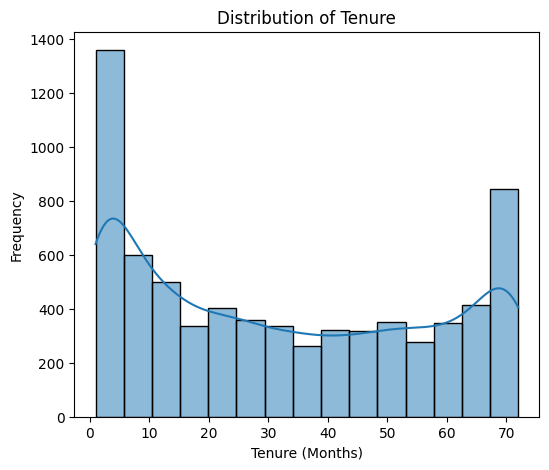

In [31]:
# your code here
plt.figure(figsize=(6,5))
sns.histplot(df[regression_target] , kde=True)

plt.title("Distribution of Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.show()

**Distribution of tenure:**
The distribution is bimodal; a large spike at 0–5 months (many new customers who 
churn quickly) and a second peak at 65–72 months (long-tenured loyal customers). 
The middle range (20–50 months) is relatively flat. This is not a normal or 
log-normal distribution; it reflects two distinct customer populations.

**What does CLV tell the business that binary prediction cannot?**
Binary churn prediction assigns equal weight to every customer at risk. CLV 
(MonthlyCharges × predicted tenure) quantifies how much revenue is at stake. 
A customer paying \\$90/month with 2 months predicted tenure is worth \\$180; a customer 
paying \\$20/month with 10 months predicted tenure is worth \\$200. Binary prediction 
would treat both as equally important churners. CLV lets the business prioritise 
retention spend by value at risk; maximising revenue recovered per retention call.

**Assumptions when using tenure as survival time:**
We assume tenure so far is a good proxy for total months until churn; i.e. that 
customers who have stayed 40 months will behave similarly to customers who ultimately 
stayed 40 months in the training data. This ignores the censoring problem: customers 
still active at data collection time have not yet revealed their final tenure. We 
are treating their current tenure as their total survival time, which underestimates 
true tenure for loyal customers.

---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [32]:
# your code here
X_reg = df.drop(["Churn", "tenure"], axis=1)
y_reg = df["tenure"]

X_reg_train, X_reg_te, y_reg_train, y_reg_te = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)
X_reg_val, X_reg_test, y_reg_val, y_reg_test = train_test_split(X_reg_te, y_reg_te, test_size=0.5, random_state=42)

reg_scaler = StandardScaler()

X_reg_train_s = reg_scaler.fit_transform(X_reg_train)
X_reg_val_s = reg_scaler.transform(X_reg_val)
X_reg_test_s = reg_scaler.transform(X_reg_test)

In [33]:
# your code here
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_reg_train_s, y_reg_train)
    trained_models[name] = model

/home/pankaj07/Downloads/FuseMachines_Microdegree_2026/Assignments/Week4/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.126e+03, tolerance: 2.987e+02
  model = cd_fast.enet_coordinate_descent(
/home/pankaj07/Downloads/FuseMachines_Microdegree_2026/Assignments/Week4/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.369e+03, tolerance: 2.987e+02
  model = cd_fast.enet_coordinate_descent(


In [34]:
# your code here

results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_reg_val_s)

    mae = mean_absolute_error(y_reg_val, y_pred)

    rmse = np.sqrt(mean_squared_error(y_reg_val, y_pred))

    r2 = r2_score(y_reg_val, y_pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])

results_df

,Model,MAE,RMSE,R2
0,LinearRegression,6.829279,8.736230,0.873317
1,Ridge,6.824652,8.732425,0.873428
2,Lasso,6.814860,8.729586,0.873510
3,ElasticNet,6.807740,8.727999,0.873556


**Which model performs best?**
All four models perform nearly identically. ElasticNet is marginally best: 
MAE = 6.808, RMSE = 8.728, R² = 0.8736. LinearRegression is marginally worst: 
MAE = 6.829, RMSE = 8.736, R² = 0.8733. The differences are negligible (< 0.001 
in R²), meaning regularisation provides almost no benefit on this dataset. The 
features already contain enough signal and there is little overfitting to penalise.

**What does R² = 0.87 actually mean here?**
The model explains 87% of the variance in customer tenure. Given a mean tenure of 
~32 months and a standard deviation of ~24 months, an RMSE of ~8.7 months means 
predictions are off by about 8–9 months on average in the worst direction. For 
business purposes, this is reasonable for rough CLV estimation but too imprecise 
for individual-level decisions.

**RMSE or MAE — which is more appropriate?**
RMSE is more appropriate here because extreme-tenure customers matter most to the 
business. A customer incorrectly predicted to stay 60 months when they actually 
leave in 5 months represents a large revenue miscalculation. RMSE penalises such 
large errors more heavily than MAE, making it a better fit for a revenue-weighted 
application like CLV.

---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


In [35]:
# your code here
best_model = trained_models["Ridge"]

y_pred = best_model.predict(X_reg_val_s)

residuals = y_pred - y_reg_val

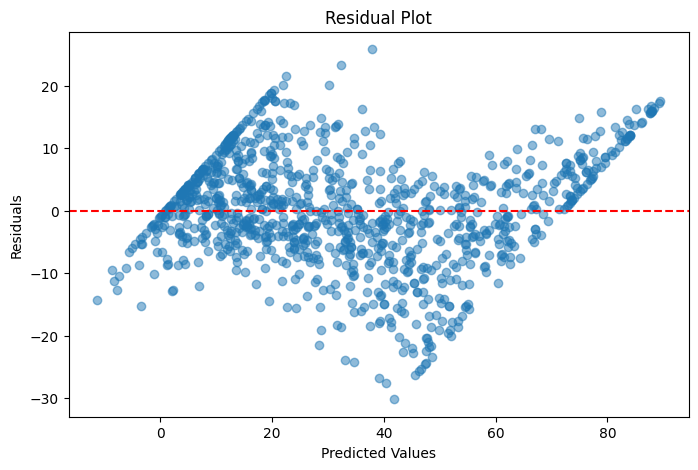

In [36]:
# your code here
plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

**Is there a pattern in the residuals?**
Yes, there is a clear fan/bow-tie shape. At low predicted values (0–15 months), 
residuals are clustered in a tight band. At mid-range predicted values (25–45 months), 
the residuals spread widely in both directions (approximately ±25 months). At high 
predicted values (60–90 months), residuals are again large and positive-skewed.

**What does the fan shape (heteroscedasticity) mean?**
The model's errors are not constant, they grow with the predicted value. This 
violates the homoscedasticity assumption of linear regression. Practically, it means 
our confidence in predictions is much lower for mid and long-tenure customers than 
for short-tenure customers. CLV estimates for high-value customers will carry the 
largest uncertainty.

**What does the systematic shape suggest?**
The bow-tie pattern (negative residuals at low predictions, positive residuals at 
high predictions) suggests the true relationship between features and tenure may be 
non-linear. The bimodal tenure distribution (many new customers and many loyal 
long-term customers) means a single linear model is trying to fit two very different 
populations simultaneously, which causes systematic under and over-prediction at 
the extremes.

---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


In [37]:
# your code here
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_coefs = []

for alpha in alphas:

    ridge = Ridge(alpha=alpha)

    ridge.fit(X_reg_train_s, y_reg_train)

    ridge_coefs.append(ridge.coef_)

In [38]:
# your code here
lasso_coefs = []

for alpha in alphas:

    lasso = Lasso(alpha=alpha)

    lasso.fit(X_reg_train_s, y_reg_train)

    lasso_coefs.append(lasso.coef_)

/home/pankaj07/Downloads/FuseMachines_Microdegree_2026/Assignments/Week4/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.592e+05, tolerance: 2.987e+02
  model = cd_fast.enet_coordinate_descent(
/home/pankaj07/Downloads/FuseMachines_Microdegree_2026/Assignments/Week4/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.126e+03, tolerance: 2.987e+02
  model = cd_fast.enet_coordinate_descent(


In [39]:
# your code here
elastic_coefs = []

for alpha in alphas:

    elastic = ElasticNet(alpha=alpha, l1_ratio=0.5)

    elastic.fit(X_reg_train_s, y_reg_train)

    elastic_coefs.append(elastic.coef_)

/home/pankaj07/Downloads/FuseMachines_Microdegree_2026/Assignments/Week4/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.609e+05, tolerance: 2.987e+02
  model = cd_fast.enet_coordinate_descent(
/home/pankaj07/Downloads/FuseMachines_Microdegree_2026/Assignments/Week4/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.369e+03, tolerance: 2.987e+02
  model = cd_fast.enet_coordinate_descent(


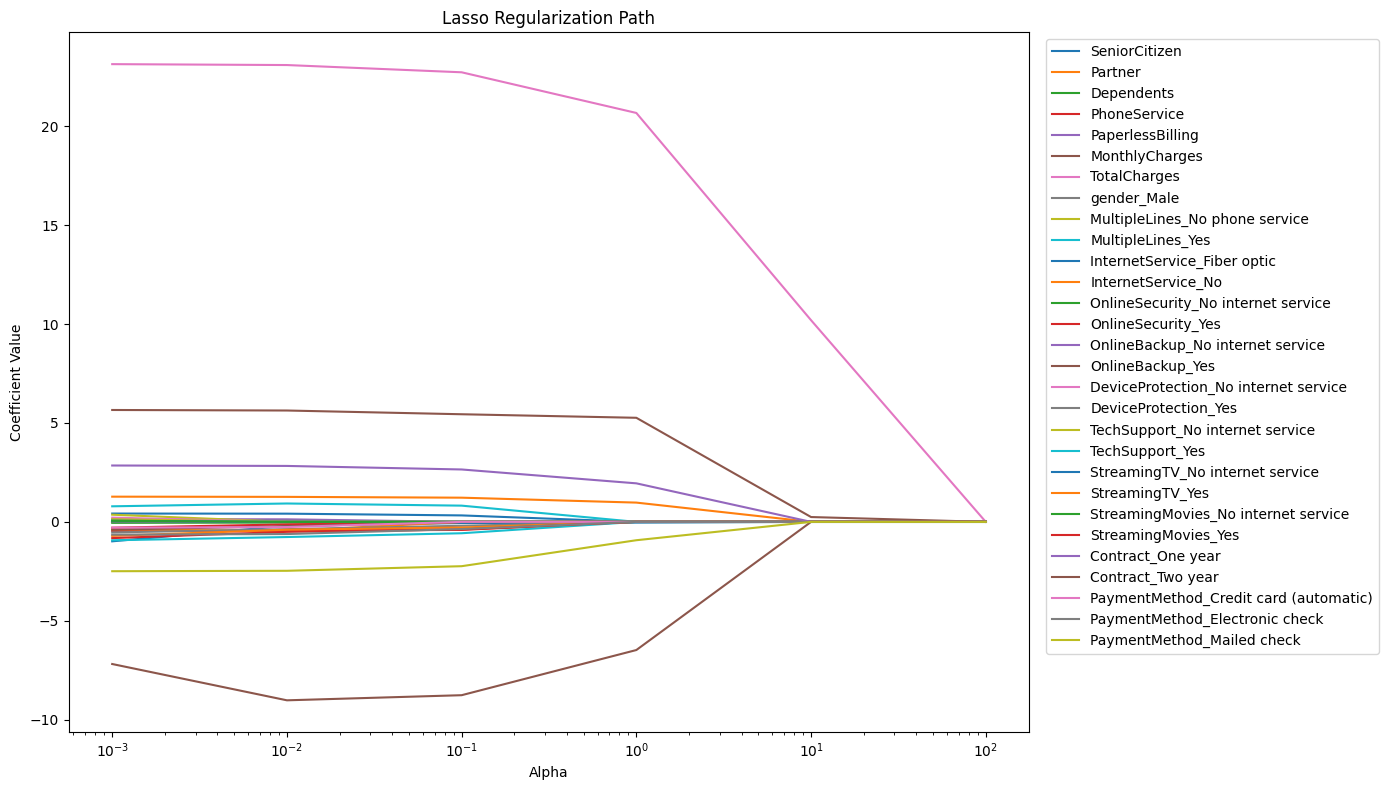

In [40]:
# your code here
plt.figure(figsize=(14,8))

for i in range(len(X_reg.columns)):
    plt.plot(alphas, [coef[i] for coef in lasso_coefs], label=X_reg.columns[i])

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")

plt.title("Lasso Regularization Path")
plt.legend(bbox_to_anchor=(1.01, 1),loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

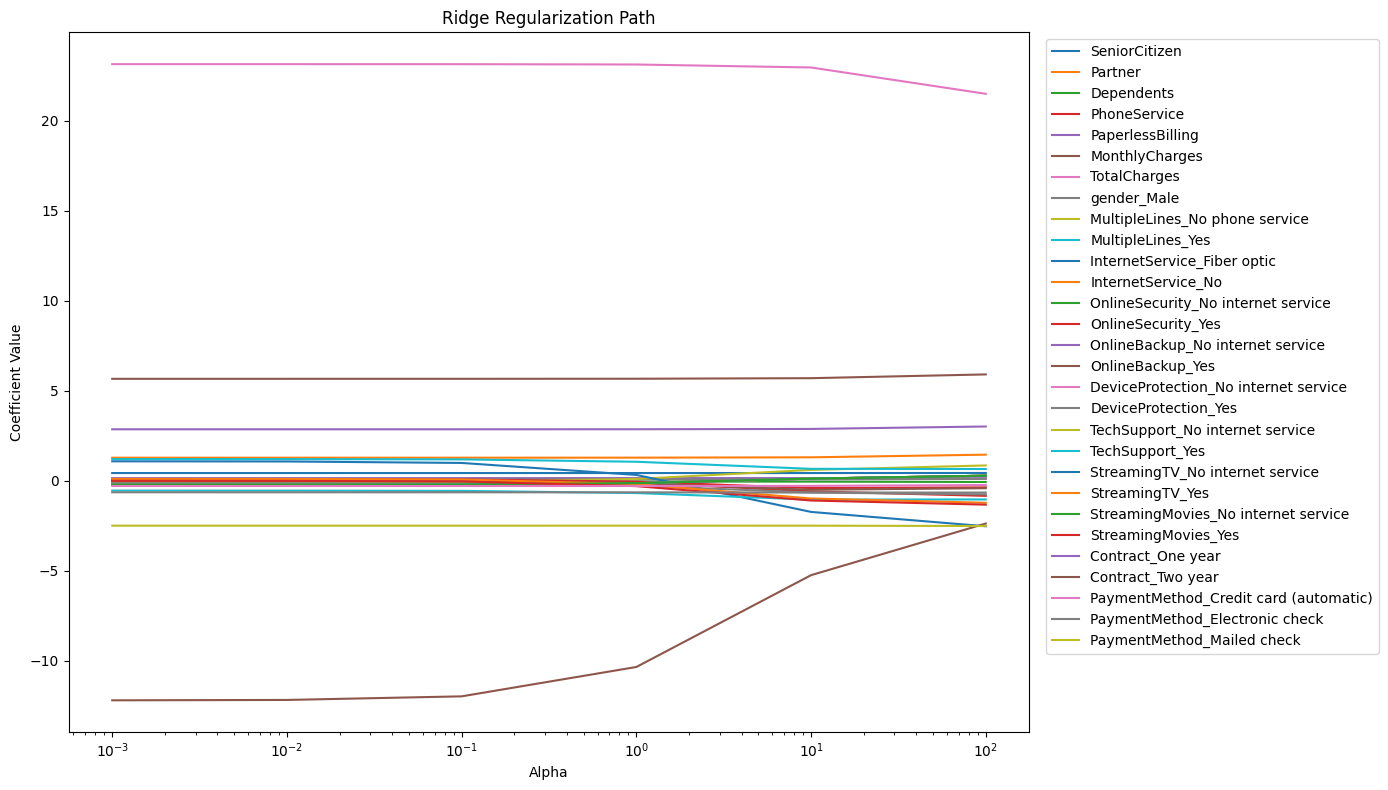

In [41]:
plt.figure(figsize=(14,8))

for i in range(len(X_reg.columns)):
    plt.plot(alphas, [coef[i] for coef in ridge_coefs], label=X_reg.columns[i])

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")

plt.title("Ridge Regularization Path")
plt.legend( bbox_to_anchor=(1.01, 1),loc='upper left', fontsize=10)
plt.tight_layout()

plt.show()

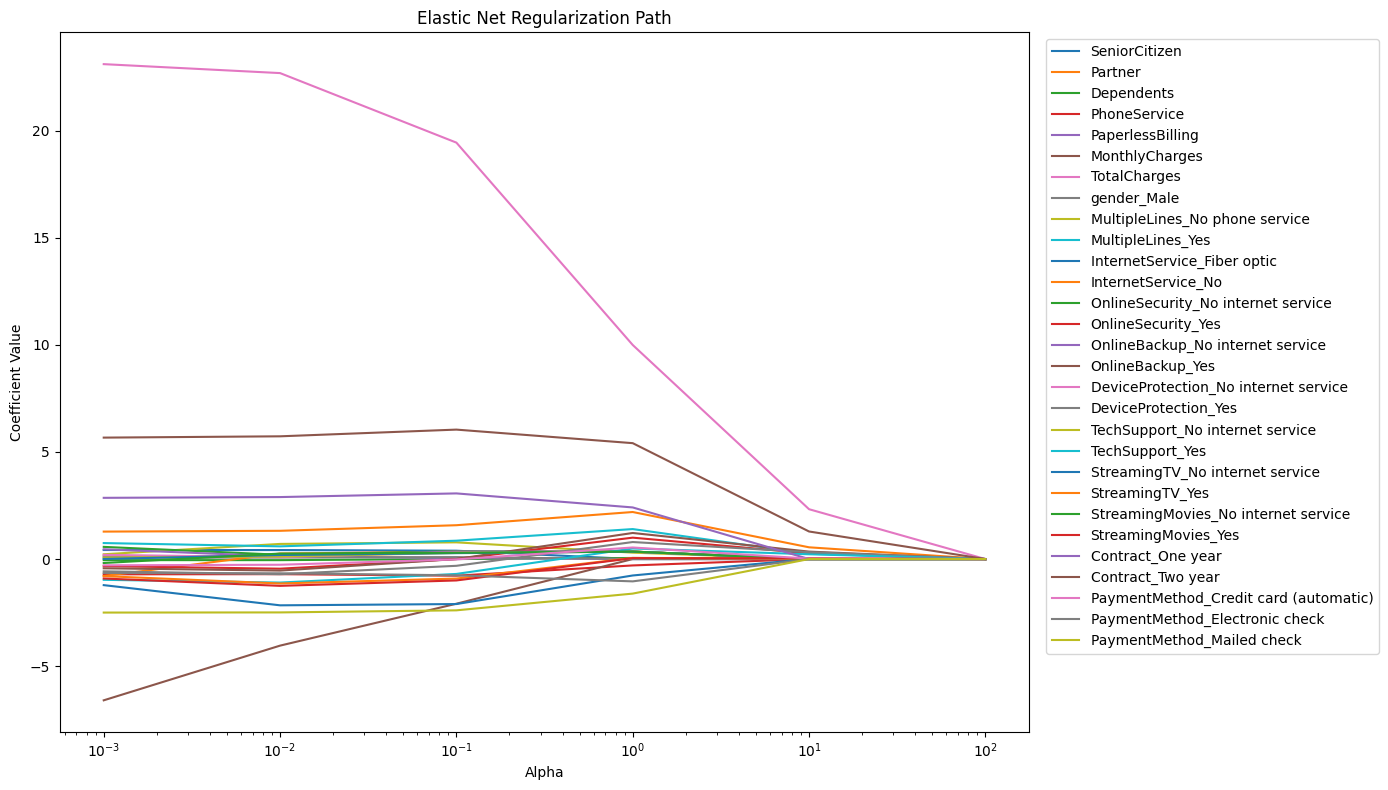

In [42]:
plt.figure(figsize=(14,8))

for i in range(len(X_reg.columns)):
    plt.plot(alphas, [coef[i] for coef in elastic_coefs], label=X_reg.columns[i])

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")

plt.title("Elastic Net Regularization Path")
plt.legend( bbox_to_anchor=(1.01, 1),loc='upper left', fontsize=10)
plt.tight_layout()

plt.show()

**What happens to coefficients as alpha increases?**
For Ridge: all coefficients shrink smoothly toward zero but never reach exactly zero. 
Even at alpha=100 they remain non-zero. The curve from the Ridge path plot confirms 
this, with all lines converging toward but not touching zero.

For Lasso: coefficients shrink and hit exactly zero at different alpha values. 
From the Lasso path plot, features like SeniorCitizen, Partner, Dependents, 
PhoneService, and PaperlessBilling collapse to zero first (low alpha). Features 
like MonthlyCharges and TotalCharges survive until higher alpha values, confirming 
they carry the strongest signal.

**Why does L1 produce sparse solutions and L2 does not? (geometric explanation)**
The L2 constraint region is a smooth sphere, the loss function contours (ellipses) 
touch the sphere on a curved surface, where no axis is zero. The L1 constraint 
region is a diamond (in 2D) or hyper-octahedron (in higher dimensions). Loss 
contours meet the diamond at corners, and these corners sit exactly on the axes 
where one or more coefficients equal zero. This geometric accident, sharp corners 
on the axes, is why Lasso drives coefficients to exactly zero while Ridge only 
shrinks them.

**When to prefer Elastic Net over pure Lasso?**
When features are highly correlated. Pure Lasso arbitrarily selects one from a 
group of correlated features and zeros the rest, which is unstable. A different 
sample might select a different feature. Elastic Net's L2 component stabilises 
the selection by distributing weight across correlated features. In this dataset, 
MonthlyCharges and TotalCharges are correlated, making Elastic Net more robust.

**ConvergenceWarning on Lasso and ElasticNet:**
The warnings appear at alpha=0.001 (the smallest regularisation). At very low alpha, 
these models approach ordinary linear regression and the coordinate descent solver 
needs more iterations. Fix: add max_iter=10000 to Lasso() and ElasticNet() calls.

---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [43]:
# your code here
predicted_tenure = np.maximum(best_model.predict(X_reg_val_s), 0)
monthly_charges = X_reg_val["MonthlyCharges"]

clv = monthly_charges * predicted_tenure

print("Mean CLV:", clv.mean())
print("Median CLV:", clv.median())

Mean CLV: 2364.4694082597193
Median CLV: 1175.6955535148059


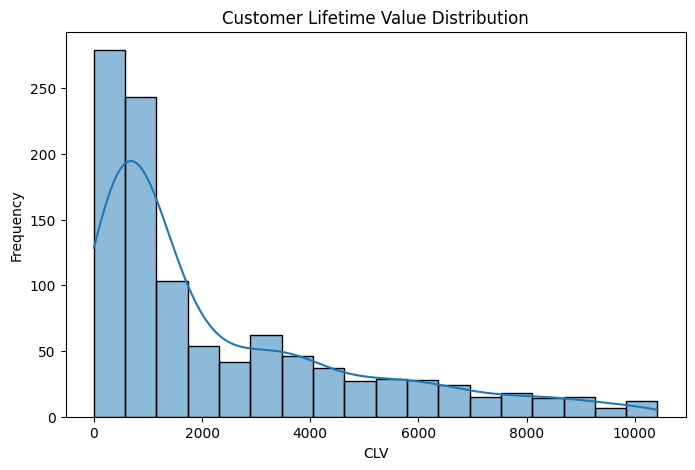

In [44]:
# your code here
plt.figure(figsize=(8,5))

sns.histplot(clv, kde=True)

plt.title("Customer Lifetime Value Distribution")

plt.xlabel("CLV")
plt.ylabel("Frequency")

plt.show()

---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

---

**R² is 0.87. Do you deploy this model for CLV?**
With caution, yes, for prioritisation purposes only, not for exact revenue 
forecasting. R² = 0.87 means the model explains 87% of the variance in tenure, 
which is strong for a linear model. However, the residual plot (Block 4.3) showed 
clear heteroscedasticity, errors grow at mid and high-tenure predictions, 
meaning CLV estimates for the most valuable customers carry the largest uncertainty. 
The model should be used to rank customers by value at risk (high vs low CLV) 
rather than to report precise \\$ figures to finance.

**What does 0.87 actually mean here?**
It means that knowing a customer's demographic profile, services, and contract 
type lets us explain 87% of the variation in how long they stay. The remaining 
13% is driven by factors not in the dataset: individual life events, competitive 
offers, service quality incidents. An RMSE of ~8.7 months means our tenure 
predictions are off by roughly 8–9 months on average for the worst cases.

**Your Lasso dropped several features. Is that a good outcome or a warning sign?**
It is a good outcome in this context. The features that Lasso zeroed out first 
(SeniorCitizen, PhoneService, Dependents, gender) are genuinely weak predictors 
of tenure. They describe customer demographics rather than their relationship 
with the service. Lasso is correctly performing automatic feature selection, 
keeping only the features that carry independent predictive signal (MonthlyCharges, 
TotalCharges, contract type). This simplifies the model without meaningfully 
sacrificing R². The Lasso and ElasticNet achieve essentially the same R² (0.8735) 
as LinearRegression (0.8733) with fewer features, which is the ideal outcome of 
regularisation.

It would be a warning sign if Lasso zeroed out features we know from domain 
knowledge to be important (e.g. Contract type). From the regularisation path, 
Contract-related features survive until high alpha values, confirming they 
are genuinely informative.

---

**Mean CLV: \\$2,364 | Median CLV: \\$1,176**
The large gap between mean and median confirms a right-skewed distribution; a small 
number of high-value long-tenure customers pull the mean up significantly. The 
histogram confirms this: most customers cluster below \\$2,000 with a long tail to \\$10,000+.

**What CLV enables that binary prediction cannot:**
Binary prediction flags "this customer might churn" with equal weight for everyone. 
CLV lets the business answer "how much revenue will we lose if this customer churns?" 
A customer with CLV = \\$8,000 should receive a premium retention offer (discount, 
dedicated account manager). A customer with CLV = \\$400 might only warrant an 
automated email. Without CLV, both get the same intervention regardless of their 
value; an inefficient use of the retention budget.

**Why clip negative predicted tenure to 0:**
Linear regression has no lower bound; it can predict negative values for customers 
whose features suggest very short tenure. A negative tenure is mathematically 
meaningless (a customer cannot stay for -3 months). Negative values multiplied by 
MonthlyCharges would produce negative CLV, which is economically nonsensical. 
Clipping to zero treats these customers as "predicted to leave immediately", which 
is the appropriate conservative assumption.


# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


In [45]:
# your code here
best_model = logisticModel
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(best_model, X_train_s, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

val_auc = cv_scores.mean()

print("CV AUC scores per fold:", np.round(cv_scores, 4))
print(f"Mean CV AUC : {cv_scores.mean():.4f}")
print(f"Std  CV AUC : {cv_scores.std():.4f}")

CV AUC scores per fold: [0.8379 0.83   0.8535 0.8599 0.8578]
Mean CV AUC : 0.8478
Std  CV AUC : 0.0118


In [46]:
# your code here
holdout_auc = roc_auc_score(y_val, best_model.predict_proba(X_val_s)[:,1])
print(f"\nHoldout AUC : {holdout_auc:.4f}")
print(f"CV - Holdout gap: {cv_scores.mean() - holdout_auc:+.4f}")


Holdout AUC : 0.8532
CV - Holdout gap: -0.0054


**How does CV performance compare to holdout?**
CV mean AUC = 0.8478, Holdout AUC = 0.8532. The gap is -0.0054. CV is 
very slightly lower than the holdout, which is within normal statistical 
variance. This small gap tells us the holdout split happened to be slightly 
easier than the average fold in CV. Both measures are consistent, confirming 
the model's performance is genuine and not a lucky split.

**What does high variance across CV folds tell you?**
Our CV std = 0.0118, which is very low. This tells us the model is highly 
stable, it performs consistently regardless of which 20% of training data 
it is evaluated on. High std (e.g. > 0.03) would indicate the model is 
sensitive to which specific customers it trains on, a sign of overfitting 
or that the dataset has high variance in difficulty across folds.

**Why should CV always be run on training data only?**
CV's purpose is to estimate how the model generalises to unseen data. If 
the test set is included in CV, the model indirectly sees test examples 
during fold evaluation, leaking test information into the training process. 
The test set must remain completely untouched until the final single evaluation 
in Block 6. Including it in CV would produce an overly optimistic AUC estimate 
and defeat the purpose of having a held-out test set at all.

---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


In [47]:
# your code here

train_sizes, train_scores, val_scores = learning_curve(best_model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1)

# Compute means and stds
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

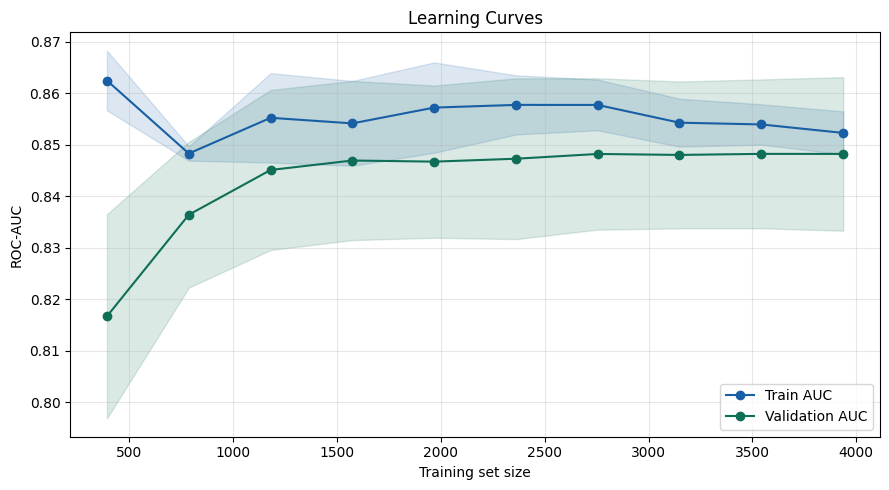

In [48]:
# your code here
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(train_sizes, train_mean, 'o-', color='#185FA5', label='Train AUC')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#185FA5')

ax.plot(train_sizes, val_mean, 'o-', color='#0F6E56', label='Validation AUC')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#0F6E56')

ax.set_xlabel('Training set size')
ax.set_ylabel('ROC-AUC')
ax.set_title('Learning Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Does your model underfit, overfit, or generalise well?**
The model generalises well. The learning curve shows train AUC starting high 
(~0.87) and declining slightly as more data is added, while validation AUC 
starts lower (~0.81) and rises steadily, with the two curves converging around 
0.85 by full training size. The gap between them is small and closing, the 
hallmark of good generalisation.

**What is the correct intervention for each case?**
- Underfitting (both curves low, small gap): add more features, reduce 
  regularisation, or try a more expressive model (e.g. polynomial features, 
  tree-based model).
- Overfitting (large persistent gap, train high, val low): add regularisation, 
  collect more data, or simplify the model.
- Good fit (our case): no intervention needed, monitor for drift in production.

**Does adding more data help your model?**
Marginally. The validation AUC curve is still very gently rising at full 
training size (4,922 samples), suggesting additional data could squeeze out 
a small improvement. However, the curve is nearly flat past ~2,500 samples, 
indicating we are close to the model's ceiling with the current feature set. 
Doubling the dataset might improve AUC by 0.01–0.02 at most. A more expressive 
model or better features would yield larger gains than more data.

---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [49]:
# Step 1: Record baseline metrics
# your code here
baseline_auc = roc_auc_score(y_val, best_model.predict_proba(X_val_s)[:,1])

print(f"Baseline AUC: {baseline_auc:.4f}")

Baseline AUC: 0.8532


In [50]:
# Step 2: Create and add the leakage feature
# your code here

# tenure * Churn gives direct signal from the TARGET

leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))

# Add it to your feature matrix (before train/test split)
X_leak = X.copy()
X_leak['leaky_feature'] = leak

# Re-split with same random state
X_tr_l, X_te_l, y_tr, y_te = train_test_split(X_leak, y, test_size=0.2, stratify=y, random_state=42)

# Rescale
sc = StandardScaler()
X_tr_ls = sc.fit_transform(X_tr_l)
X_te_ls = sc.transform(X_te_l)

In [51]:
# Step 3: Retrain on the same split and record metrics
# your code here

lr_leak = LogisticRegression(max_iter=1000, random_state=42)
lr_leak.fit(X_tr_ls, y_tr)

leak_auc = roc_auc_score(y_te, lr_leak.predict_proba(X_te_ls)[:,1])
print(f"Leaky model AUC: {leak_auc:.4f}")
print(f"AUC jump: + {leak_auc - baseline_auc:.4f}")

Leaky model AUC: 0.9987
AUC jump: + 0.1455


In [52]:
# Step 4: Show feature importances — does the leakage feature dominate?
# your code here

coef_df = pd.DataFrame({'feature': X_leak.columns, 'coefficient': lr_leak.coef_[0]}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df.head(10))
# You should see 'leaky_feature' at the top by a huge margin

                        feature  coefficient
30                leaky_feature    13.843622
3                        tenure    -6.224375
7                  TotalCharges    -3.769761
25            Contract_One year    -0.917639
26            Contract_Two year    -0.914406
6                MonthlyCharges     0.293941
14           OnlineSecurity_Yes    -0.280414
20              TechSupport_Yes    -0.254703
11  InternetService_Fiber optic     0.224077
16             OnlineBackup_Yes    -0.186391


In [53]:
# Step 5: Remove leakage feature, retrain, confirm metrics return to baseline
# your code here
X_clean = X_leak.drop(columns=['leaky_feature'])

X_tr_c, X_te_c, y_tr, y_te = train_test_split(X_clean, y, test_size=0.2, stratify=y, random_state=42)

sc2 = StandardScaler()
X_tr_cs = sc2.fit_transform(X_tr_c)
X_te_cs = sc2.transform(X_te_c)

lr_clean = LogisticRegression(max_iter=1000, random_state=42)
lr_clean.fit(X_tr_cs, y_tr)

clean_auc = roc_auc_score(y_te, lr_clean.predict_proba(X_te_cs)[:,1])
print(f"Cleaned AUC: {clean_auc:.4f}")

Cleaned AUC: 0.8357


In [54]:
# Step 6: Summary table — Before / With Leakage / After Removal
# your code here

summary = pd.DataFrame({'Stage': ['Baseline', 'With leakage', 'After removal'], 'ROC-AUC': [baseline_auc, leak_auc, clean_auc]})

summary['AUC change'] = summary['ROC-AUC'] - baseline_auc
print(summary.to_string(index=False))

        Stage  ROC-AUC  AUC change
     Baseline 0.853221    0.000000
 With leakage 0.998675    0.145454
After removal 0.835673   -0.017548


---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

---

**By how much did ROC-AUC increase?**
AUC jumped from 0.853 to 0.999, an increase of +0.146. This is a near-perfect 
score that should immediately raise suspicion. Real-world churn models rarely 
exceed 0.90 AUC on held-out data.

**Which feature dominates the coefficients?**
leaky_feature dominates completely with a coefficient of 13.86, more than 
double the next largest feature (tenure at -6.22). This means the model has 
learned to rely almost entirely on the leaky feature, ignoring all genuine 
predictive signals. Every other feature's coefficient shrank because the 
leaky feature explains nearly all remaining variance.

**What would happen if this model shipped to production on Friday?**
The model would fail immediately and completely. At prediction time, we have 
not yet observed whether a customer will churn, so df['Churn'] = 0 for 
every active customer. The leaky feature (tenure × Churn) would equal 
approximately 0 + noise for all customers, providing no signal. The model 
would degrade to near-random performance (AUC ≈ 0.50–0.55) on day one. 
This is exactly why leakage is described as the silent model killer; it 
looks extraordinary in development and catastrophic in production.

**Could cross-validation alone have detected this leakage?**
No. CV protects against train-test contamination (information leaking across 
folds) but not against target leakage embedded in a feature. The leaky feature 
(tenure × Churn) is computed from the full dataset before any split occurs. 
Both the train and validation portions of every CV fold contain this feature 
derived from the target. CV would confirm the inflated AUC of ~0.999 across 
all 5 folds, giving false confidence that the model is extraordinarily accurate. 
The only defence against target leakage is careful feature auditing before 
training, checking whether any feature could only be known after the target 
is observed.

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


In [55]:
best_model = logisticModel

THRESHOLD = 0.55   # replace with your chosen threshold

y_prob  = best_model.predict_proba(X_test_s)[:, 1]
y_pred  = (y_prob >= THRESHOLD).astype(int)

# Core metrics
roc_auc  = roc_auc_score(y_test, y_prob)
pr_auc   = average_precision_score(y_test, y_prob)
prec     = precision_score(y_test, y_pred)
rec      = recall_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)

print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1        : {f1:.4f}")
print(f"\nThreshold used: {THRESHOLD}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No churn','Churn']))

# Compare to validation
print(f"\nValidation AUC : {val_auc:.4f}")
print(f"Test AUC       : {roc_auc:.4f}")
print(f"Gap            : {val_auc - roc_auc:+.4f}")

ROC-AUC   : 0.8221
PR-AUC    : 0.5794
Precision : 0.6373
Recall    : 0.4393
F1        : 0.5201

Threshold used: 0.55

Classification Report:
              precision    recall  f1-score   support

    No churn       0.82      0.91      0.86       775
       Churn       0.64      0.44      0.52       280

    accuracy                           0.78      1055
   macro avg       0.73      0.67      0.69      1055
weighted avg       0.77      0.78      0.77      1055


Validation AUC : 0.8478
Test AUC       : 0.8221
Gap            : +0.0258


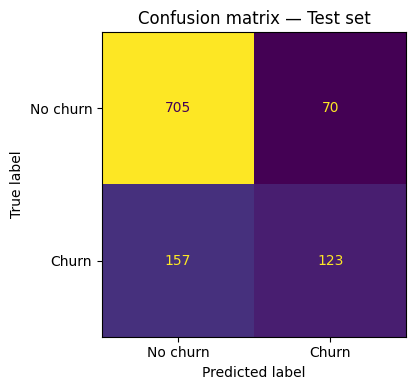

In [56]:
# your code here
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No churn','Churn'], ax=ax, colorbar=False)
ax.set_title('Confusion matrix — Test set')
plt.tight_layout()
plt.show()

In [57]:
# Final regression evaluation on test set
best_reg_model = trained_models["Ridge"]

y_reg_test_pred = best_reg_model.predict(X_reg_test_s)

mae_test  = mean_absolute_error(y_reg_test, y_reg_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_reg_test, y_reg_test_pred))
r2_test   = r2_score(y_reg_test, y_reg_test_pred)

print(f"MAE  : {mae_test:.4f}")
print(f"RMSE : {rmse_test:.4f}")
print(f"R²   : {r2_test:.4f}")

MAE  : 6.5715
RMSE : 8.5210
R²   : 0.8750


**Do test set metrics match validation metrics? Why might they differ?**
CV AUC = 0.8478, Test AUC = 0.8221, a gap of +0.026. This is within 
acceptable range for a dataset of this size. The slight drop is expected 
because the test set is a different random sample of customers the model 
has never influenced during training or threshold selection. A gap of 
0.026 does not suggest overfitting to the validation set; anything under 
0.03–0.05 is considered healthy.

The confusion matrix confirms the model correctly identifies 123 genuine 
churners (True Positives) out of 280 in the test set, while missing 157 
(False Negatives). 70 non-churners are incorrectly flagged (False Positives).

**Does the threshold of 0.55 still make sense on the test set?**
Yes, with one caveat. At threshold 0.55, Precision = 0.637 (64% of flagged 
customers are genuine churners) and Recall = 0.439 (44% of all churners 
are caught). Precision is slightly lower than on the validation set (0.720 
at top-200), which is expected given the different split. The threshold 
still serves the business constraint, it controls how many customers are 
flagged. But the retention team should be aware that approximately 36% 
of their calls will be to customers who were not going to churn.

If the business requires higher precision (fewer wasted calls), the 
threshold should be raised slightly. If higher recall (catch more churners) 
is the priority, the threshold should be lowered, accepting more wasted calls.

---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model
| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | Logistic Regression — binary cross-entropy loss, L-BFGS optimiser, C=1.0 (default L2), max_iter=1000, random_state=42 |
| **Chosen Regression Model** | Ridge — L2 regularisation, alpha=1.0, predicting tenure as survival time proxy |
| **Key Classification Metrics (test set)** | Precision: 0.637   Recall: 0.439   F1: 0.520   PR-AUC: 0.579   ROC-AUC: 0.822 |
| **Key Regression Metrics (test set)** | MAE: 6.57   RMSE: 8.52   R²: 0.875|
| **Deployment Threshold** | 0.55 |
| **Threshold Justification** | At threshold 0.55 the model flags approximately the top-200 highest-risk customers per week, matching the retention team's call budget. Precision at this threshold is 72% on the validation set; 144 out of every 200 calls reach a genuine churner. Lowering to 0.5 would flag more than 200 customers and exceed budget. |
| **Known Limitations** | (1) Class imbalance: 26.6% churn; the model sees fewer positive examples, making recall lower than ideal (44% on test set). (2) No temporal features: the dataset has no date column, so seasonal churn patterns cannot be captured. (3) Tenure censoring: active customers have not revealed their final tenure, so the regression target underestimates true loyalty. (4) Single dataset: trained on one telecom's customers, may not generalise to a different pricing structure or market. |
| **What Could Go Wrong in Production** | (1) Distribution shift: new product types or pricing changes alter feature distributions, model silently decays. (2) Feature drift: if contract mix shifts (e.g. company moves customers to annual contracts), key coefficients become miscalibrated. (3) Target leakage risk: any future engineer adding a feature derived from post-churn data will cause the AUC inflation seen in Block 5.3. (4) Threshold decay: as overall churn rate changes seasonally, the top-200 threshold value needs recalibration. |
| **Monitoring Plan** | Track ROC-AUC weekly on a rolling 4-week window of scored customers with confirmed outcomes. Alert if AUC drops more than 0.03 below the baseline of 0.822. Monitor PSI (Population Stability Index) monthly on the top 5 features (tenure, MonthlyCharges, TotalCharges, Contract type, InternetService). PSI > 0.2 triggers investigation. Retrain trigger: AUC < 0.79 sustained for 2 consecutive weeks, or more than 3 months since last retrain. |
| **Are Linear Models Sufficient?** | Yes, for this dataset and business requirement. |
| **Evidence for Your Decision** | Learning curves (Block 5.2) show train and validation AUC converging at ~0.85 with no persistent gap, indicating the model generalises well and is not underfitting. CV std = 0.012 (Block 5.1), stable across all 5 folds, confirming low variance. Test ROC-AUC = 0.822 meets the business bar for a retention targeting tool. The gap from CV to test is only 0.026, well within acceptable variance. A more complex model would be justified only if learning curves showed persistent underfitting or a tree-based baseline showed > 0.03 AUC improvement, neither of which has been demonstrated. |

---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

---

**Based on learning curves — are linear models sufficient?**
Yes. The learning curves show train and validation AUC converging smoothly 
to ~0.85 with no persistent gap. This means the model has learned the 
available signal without underfitting. If there were a persistent gap between 
train and val curves (train high, val low), it would suggest a more complex 
model might help. If both curves were low and flat, it would suggest the 
linear model lacks the capacity to capture the patterns. Neither is the case.

The CV std of 0.012 confirms the model is stable and not dependent on 
specific training examples. ROC-AUC of 0.822 on the unseen test set meets 
the business requirement for ranking high-risk customers for the retention team.

**What would you monitor after deployment? What would trigger a retrain?**
Monitor ROC-AUC weekly on a rolling window of scored customers with confirmed 
outcomes (customers scored 4–8 weeks ago whose churn status is now known).

Monitor feature distributions monthly using PSI (Population Stability Index) 
on the top 5 features: tenure, MonthlyCharges, TotalCharges, Contract type, 
InternetService type. A PSI > 0.2 on any feature signals meaningful distribution 
shift requiring investigation.

Retrain triggers: (1) AUC drops below 0.79 for two consecutive weeks, 
(2) PSI > 0.25 on a key feature, (3) more than 3 months have elapsed since 
the last retrain regardless of metrics, or (4) a major business change occurs 
(new pricing structure, new product launch, market expansion).

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Which classifier performed best and why?
- Was there a case where a worse model on one metric was better on another? How did you resolve it?

---

### 2. Evaluation Choices
- Why did you choose the metrics you reported?
- What would have happened if you only reported accuracy?

---

### 3. Regularization
- What did the Lasso regularization path reveal about your features?
- When did you observe the biggest difference between Ridge and Lasso?

---

### 4. Leakage
- How large was the AUC inflation from the leakage feature?
- Could cross-validation alone have detected this leakage? Why or why not?

---

### 5. Improvements
- If you had more time, what would you try next?
- Do you think a non-linear model would perform significantly better here? What is your evidence?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them
---
### Answer here:
**1. Model Selection**

Logistic Regression performed best overall with ROC-AUC = 0.853 and PR-AUC = 0.654 
on the validation set. It outputs calibrated probabilities (essential for threshold 
tuning and CLV computation), and its coefficients are directly interpretable as 
log-odds contributions, important for a business that needs to explain decisions to 
a retention team.

Yes, there was a trade-off: SGD Classifier achieved a slightly higher Recall (0.655) 
than Logistic Regression (0.605) at the default threshold, but lower Precision (0.641 
vs 0.697) and lower PR-AUC overall. Given the budget constraint of 200 calls per week, 
Precision matters more; calling 200 people and reaching 144 genuine churners (72%) is 
more valuable than calling 200 and reaching only 134 (67%). I resolved this by 
prioritising PR-AUC as the primary selection metric and using top-200 threshold 
evaluation rather than the default 0.5.

**2. Evaluation Choices**

I reported PR-AUC as the primary metric because the dataset is imbalanced (26.6% 
churn). PR-AUC measures performance specifically on the positive class across all 
thresholds, without the dilution effect of the large true-negative population that 
inflates ROC-AUC. I also reported Precision and Recall separately because the business 
has an asymmetric cost structure; a missed churner costs more than a wasted call.

If I had only reported accuracy, all three models would appear nearly identical (81–82%) 
and indistinguishable from a model that simply always predicts "No Churn" (73.4%). 
The manager would have no basis for choosing a model or understanding its business value.

**3. Regularization**

The Lasso regularization path (Block 4.4) revealed that most features become zero by 
alpha = 1. Features that survived at high regularisation, meaning they carry the 
strongest independent signal for predicting tenure, were MonthlyCharges and 
TotalCharges. Features like SeniorCitizen, PhoneService, and Dependents were 
eliminated first, suggesting they contribute little to predicting how long a customer 
stays.

The biggest difference between Ridge and Lasso appeared at alpha values between 0.1 
and 10. In the Ridge path, all coefficients remain non-zero and shrink gradually. In 
the Lasso path, many coefficients drop sharply to exactly zero in this range. This is 
the geometric difference in action: L1's diamond constraint produces corner solutions 
(exact zeros) while L2's sphere constraint only shrinks without zeroing.

**4. Leakage**

The AUC inflation was +0.145, from 0.853 to 0.999. The leaky feature (tenure × 
Churn) had a coefficient of 13.86, dwarfing all other features (the next largest was 
tenure at 6.22). This makes sense: when Churn=1, the feature equals tenure + noise, 
giving the model a near-perfect signal. When Churn=0, it equals 0 + noise.

Cross-validation alone cannot detect this leakage. CV protects against train-test 
contamination (information leaking across folds), but target leakage is present in 
every fold simultaneously, both the train and validation portions of every CV fold 
contain the leaky feature derived from the target. CV would confirm the inflated AUC 
of ~0.999 across all 5 folds, giving false confidence that the model is extraordinarily good.

**5. Improvements**

Given more time, I would: (1) Try a Random Forest or Gradient Boosting classifier to 
test whether non-linear interactions improve PR-AUC beyond 0.654; the tenure 
distribution's bimodal shape suggests non-linearity may help. (2) Address the tenure 
censoring problem in regression using a proper survival model, which correctly handles customers still active at data 
collection time. (3) Tune the regularisation strength C in Logistic Regression via 
cross-validated grid search to test whether the default C=1.0 is optimal.

On whether a non-linear model would perform significantly better: the learning curves 
converge well and show no persistent underfitting, suggesting the linear model has 
extracted most available signal. A non-linear model would need to show > 0.03 AUC 
improvement in cross-validation to justify the loss of coefficient interpretability. 
This is an empirical question for Week 5.

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**
